# Effective Dimensionality (ED) analysis

This notebook estimates time-resolved effective dimensionality (ED) from PCA eigenvalues using four ED estimators following Del Giudice (2021).

**Input:**

- `results/eigenvalues/all_events/eigenval_event_all_events_timestamp_all_7_variables.csv` (generated by `2_pca.ipynb`)

**Main outputs:**

- ED estimator tables across time (for analysis and comparison)
- ED and eigenvalue visualizations (optionally saved under `results/`)

**Run context**

Run this notebook from the project root directory so relative paths resolve correctly.

In [12]:
import gc
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from xarray.util.generate_ops import inplace
import re
warnings.simplefilter(action='ignore', category=FutureWarning)
import dataframe_image as dfi
import os
import math
from  matplotlib.ticker import PercentFormatter
from typing import Dict, Iterable, List, Optional
sns.set_style("white")
# sns.set_context("notebook")
sns.set_theme(style="ticks", palette="husl")
from pathlib import Path
import cv2
from scipy.stats import chi2, norm
# set dask dashboard
import dask
import dask.array as da
dask.config.set({'dataframe.query-planning': True})
import dask.dataframe as dd
from scipy.spatial.transform import Rotation as R
# pd.options.mode.chained_assignment = None  # default='warn'
from dask.distributed import Client
client = Client()  # start distributed scheduler locally.
client

/Users/johnmadrid/dev/phd_main/lib/python3.11/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 55940 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:55940/status,
Dashboard: http://127.0.0.1:55940/status,Workers: 4
Total threads: 16,Total memory: 64.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:55941,Workers: 4
Dashboard: http://127.0.0.1:55940/status,Total threads: 16
Started: Just now,Total memory: 64.00 GiB
Comm: tcp://127.0.0.1:55952,Total threads: 4
Dashboard: http://127.0.0.1:55955/status,Memory: 16.00 GiB
Nanny: tcp://127.0.0.1:55944,


# 1. Load Data

In [3]:
def init_results_dirs(base_dir: str = "results", event: str | None = None):
    """
    Initialize results directory structure with per-event subfolders.

    Structure created:
        results/
          cleaned_new/ <event_dir>
          variances/   <event_dir>
          components/  <event_dir>
          eigenvalues/ <event_dir>
          biplots/     <event_dir>
          cos_plots/   <event_dir>

    Where <event_dir> is "event_<event>" if event is provided, otherwise "all_events".

    Args:
        base_dir: Base results directory.
        event: Optional event name.

    Returns:
        dict: Mapping of category name to absolute event-specific directory path. Includes key "base".
    """
    base_abs = os.path.abspath(base_dir)
    os.makedirs(base_abs, exist_ok=True)

    event_dirname = f"event_{event}" if (event and len(str(event)) > 0) else "all_events"

    categories = [
        "cleaned_new",
        "variances",
        "components",
        "eigenvalues",
        "biplots",
        "cos_plots",
    ]

    dirs: dict[str, str] = {"base": base_abs}
    for cat in categories:
        cat_parent = os.path.join(base_abs, cat)
        os.makedirs(cat_parent, exist_ok=True)
        cat_event_dir = os.path.join(cat_parent, event_dirname)
        os.makedirs(cat_event_dir, exist_ok=True)
        dirs[cat] = cat_event_dir

    return dirs

In [4]:
# Use init_results_dir() to get the base results directory, then find the biplots/event_one folder
results_dir = init_results_dirs()
print(results_dir)
# If init_results_dirs() returns a dict, get the correct path value (e.g., 'base' or 'results')
if isinstance(results_dir, dict):
    # Try common keys, adjust as needed for your project
    results_dir = results_dir.get('base') or results_dir.get('results') or next(iter(results_dir.values()))
# Ensure results_dir is a Path object
results_dir = Path(results_dir)
print(results_dir)
# List file names in the 'eigenvalues' folder
eigen_results_path = results_dir/'eigenvalues'
eigen_results_files = os.listdir(eigen_results_path)

# Print the file names
print("Files in 'variances' folder:", eigen_results_files)
# Load eigenvalues df
# Find CSV files in the 'all_events' folder
all_events_eigv_folder = eigen_results_path / 'all_events'

# Print the names of all CSV files in the folder
csv_files = list((all_events_eigv_folder).glob("*.csv"))
print("CSV files in 'all_events' folder:")
for f in csv_files:
    print(f.name)

# Load all CSV files into a single DataFrame
eigenv_df = dd.read_csv(all_events_eigv_folder / "eigenval_event_all_events_timestamp_all_7_variables.csv").compute()
eigenv_df

{'base': '/Users/johnmadrid/GitHub/pca-driving-behavior/results', 'cleaned_new': '/Users/johnmadrid/GitHub/pca-driving-behavior/results/cleaned_new/all_events', 'variances': '/Users/johnmadrid/GitHub/pca-driving-behavior/results/variances/all_events', 'components': '/Users/johnmadrid/GitHub/pca-driving-behavior/results/components/all_events', 'eigenvalues': '/Users/johnmadrid/GitHub/pca-driving-behavior/results/eigenvalues/all_events', 'biplots': '/Users/johnmadrid/GitHub/pca-driving-behavior/results/biplots/all_events', 'cos_plots': '/Users/johnmadrid/GitHub/pca-driving-behavior/results/cos_plots/all_events'}
/Users/johnmadrid/GitHub/pca-driving-behavior/results
Files in 'variances' folder: ['event_one', '.DS_Store', 'all_events']
CSV files in 'all_events' folder:
eigenval_event_all_events_timestamp_all_7_variables.csv
stddev_event_all_events_timestamp_all_7_variables.csv


,eigen_val1,eigen_val2,eigen_val3,eigen_val4,eigen_val5,eigen_val6,eigen_val7,Time,Event
0,1.722745,1.304461,1.256684,0.848276,0.770024,0.671892,0.450653,0.00,NoEv
1,1.744587,1.291857,1.217038,0.829385,0.765112,0.728396,0.448359,0.02,NoEv
2,1.774291,1.288383,1.218734,0.806472,0.776707,0.699494,0.460654,0.04,NoEv
3,1.728854,1.379942,1.280174,0.787086,0.770990,0.598830,0.478860,0.06,NoEv
4,1.731458,1.335319,1.275441,0.785825,0.762532,0.644281,0.489877,0.08,NoEv
...,...,...,...,...,...,...,...,...,...
23712,1.752444,1.357745,1.013896,0.973743,0.759734,0.740736,0.426524,474.24,ten_AF
23713,1.748018,1.336871,1.010269,0.963393,0.788962,0.745083,0.432227,474.26,ten_AF
23714,1.721947,1.321324,0.998838,0.968213,0.791138,0.763234,0.460128,474.28,ten_AF
23715,1.718867,1.309034,1.021306,0.947700,0.814435,0.741352,0.472129,474.30,ten_AF


# 2. Calculate ED

In [5]:
def compute_ED_estimators(eigenvalues):
    """
    Compute Effective Dimensionality estimators from eigenvalues.
    This function follows Del Giudice (2021) implementation in R language
    Parameters:
    eigenvalues (list or array): List of eigenvalues.
    Returns:
    dict: Dictionary containing various ED estimators (n1, n2, nInf, nC).
    """
    output = {}

    # Make eigenvalues a numpy array for easier manipulation
    eigen_val = np.array(eigenvalues)

    # Compute ED estimators
    K = len(eigen_val)
    eigen_sum = np.sum(eigen_val)
    norm_eigen_val = eigen_val / eigen_sum

    # Calculate variance using the K/(K-1) adjustment
    eigen_var = np.var(eigen_val, ddof=0) * ((K - 1) / K)

    # Calculate the four different estimators
    output["n1"] = np.prod(norm_eigen_val ** (-norm_eigen_val))
    output["n2"] = (eigen_sum ** 2) / np.sum(eigen_val ** 2)
    output["nInf"] = eigen_sum / np.max(eigen_val)
    output["nC"] = K - ((K ** 2) / (eigen_sum ** 2)) * eigen_var

    return output

# Process eigenvalues_df DataFrame
def calculate_ED(df):
    """
    Process eigenvalues from a DataFrame to compute ED estimators per timestamp.
    Parameters:
    df (DataFrame): A DataFrame containing eigenvalues and a Time column.
    Returns:
    DataFrame: A new DataFrame containing ED estimators and the Time column.
    """
    results = []

    for _, row in df.iterrows():
        # Exclude Time, Event col and handle NaNs (if any)
        eigenvalues = row[:-2].dropna()
        time = row['Time']
        event = row['Event']
        ed_estimators = compute_ED_estimators(eigenvalues)
        ed_estimators['Time'] = time
        ed_estimators['Event'] = event
        results.append(ed_estimators)

    # Convert results to a DataFrame
    processed_df = pd.DataFrame(results)
    return processed_df

# Apply function to eigenvalues_df
ed_df = calculate_ED(eigenv_df)

# Display the resulting DataFrame
ed_df

,n1,n2,nInf,nC,Time,Event
0,6.446273,6.006371,4.077640,6.858204,0.00,NoEv
1,6.458581,6.018998,4.026588,6.860299,0.02,NoEv
2,6.442176,5.982518,3.959178,6.854221,0.04,NoEv
3,6.396214,5.921258,4.063232,6.843845,0.06,NoEv
4,6.433138,5.972878,4.057121,6.852602,0.08,NoEv
...,...,...,...,...,...,...
23712,6.457123,6.019164,4.008585,6.860327,474.24,ten_AF
23713,6.477379,6.050539,4.018735,6.865496,474.26,ten_AF
23714,6.521014,6.117847,4.079580,6.876406,474.28,ten_AF
23715,6.532146,6.133946,4.086891,6.878980,474.30,ten_AF


## Visualize ED

In [25]:
from matplotlib.ticker import LinearLocator, FormatStrFormatter
def create_combined_visualization(eigenvalues_df, ed_df, features=None,
                                  cmap="viridis", save=False, save_name='ED_and_eigval_magnitudes'):
    """
    Creates a two-row subplot with effective dimensionality visualization on top
    and eigenvalues heatmap on the bottom, using `constrained_layout` for better spacing.

    Parameters:
    -----------
    eigenvalues_df : pandas.DataFrame
        DataFrame containing eigenvalues with 'Time' as one column and eigenvalue columns.
    ed_df : pandas.DataFrame
        DataFrame containing ED estimates with columns ['Time', 'n1', 'n2', 'nInf', 'nC'].
    features : list, optional
        List of features used in the analysis (for title display).
    cmap : str, optional
        Colormap to use for the heatmap, default is "viridis".
    save : bool, optional
        Whether to save the plot as a file, default is False.

    Returns:
    --------
    None
    """

    # Find the earliest and latest timestamps across both dataframes
    time_min = min(ed_df['Time'].min(), eigenvalues_df['Time'].min())
    time_max = max(ed_df['Time'].max(), eigenvalues_df['Time'].max())

    # Set up the figure with constrained layout
    fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=(16, 7), sharex=True,
                                            gridspec_kw={'height_ratios': [2.25, 0.8]}, constrained_layout=True)

    # =====================================================
    # Top subplot - Effective Dimensionality
    # =====================================================

    # Create a mapping for LaTeX-style labels
    label_mapping = {
        'n1': '$n_{1}$',
        'n2': '$n_{2}$',
        'nInf': '$n_{\\infty}$',
        'nC': '$n_{C}$'
    }
    eddf = ed_df.drop(columns=['Event'], inplace=False)
    # Convert ed_df to long format for lineplot
    ed_long = eddf.melt(id_vars=['Time'], var_name='Estimator', value_name='Value')
    ed_long['Estimator'] = ed_long['Estimator'].map(label_mapping)

    # Plot all lines at once, differentiating by hue
    sns.lineplot(data=ed_long, x='Time', y='Value', hue='Estimator', style='Estimator',
                 palette=['#2F4858', '#D83456', '#586A73', '#86888A'], linewidth=1.5, ax=ax_top)

    # Add vertical lines at the start of each event (excluding 'NoEv')
    events = eigenvalues_df[~eigenvalues_df['Event'].str.contains('NoEv|BE|AF')]['Event'].unique()
    for i, event in enumerate(events):
        min_ts = eigenvalues_df[eigenvalues_df['Event'] == event]['Time'].min()
        max_ts = eigenvalues_df[eigenvalues_df['Event'] == event]['Time'].max()
        ax_top.axvline(x=max_ts, color='#7f7f7f', linestyle='--', linewidth=2)
        ax_top.axvline(x=min_ts, color='#7f7f7f', linestyle='--', linewidth=2)
        # Shade the area inside the event segment
        ax_top.fill_betweenx([min(ed_df['nInf']), max(ed_df['nC'])], min_ts, max_ts, color='#EEE59F', alpha=0.3)

    # Drop Event column
    eigenvalues_df = eigenvalues_df.drop(columns=['Event'], inplace=False)
    # Get the eigenvalue columns
    time_col = 'Time'

    eigenvalue_cols = [col for col in eigenvalues_df.columns if col != time_col]

    # Apply styling to top plot
    n_features = len(eigenvalue_cols)  # if features is not None else "unknown number of"
    ax_top.set_title(f"Effective dimensionality over time, {n_features} variables", fontsize=12)
    ax_top.set_ylabel("Effective Dimensionality", fontsize=10)
    ax_top.set_xlim(time_min, time_max)

    # Remove spines and unnecessary gridlines
    sns.despine(ax=ax_top, offset=0, trim=False)

    # =====================================================
    # Bottom subplot - Eigenvalues Heatmap
    # =====================================================

    # Create a matrix for the heatmap
    matrix = eigenvalues_df[eigenvalue_cols].values.T

    # Create the heatmap in the bottom subplot
    im = ax_bottom.imshow(matrix, aspect='auto', cmap=cmap,
                          extent=[time_min, time_max,
                                  len(eigenvalue_cols) - 0.5, -0.5])

    # Set the title and labels for the bottom plot
    ax_bottom.set_title("Eigenvalues magnitudes over time", fontsize=10)
    ax_bottom.set_xlabel('Time (s)', fontsize=10)
    ax_bottom.set_ylabel('Eigenvalue', fontsize=10)

    # Generate tick positions for y-axis based on eigenvalue indices with LaTeX formatting
    y_ticks = np.arange(0, len(eigenvalue_cols))
    ax_bottom.set_yticks(y_ticks)
    ax_bottom.set_yticklabels([f'$\\lambda_{{{i + 1}}}$' for i in range(len(eigenvalue_cols))])

    # Change axes parameters to be spaced 50
    x_min = min(eigenvalues_df[time_col])
    x_max = max(eigenvalues_df[time_col])
    ax_bottom.set_xlim(x_min, x_max)
    # Find the nearest even number for x_min
    if x_min % 2 != 0:  # If not even
        x_min = round(x_min+0.3) # Round up to the nearest even number
    tick_interval = 50
    ax_bottom.set_xticks(np.arange(x_min, x_max, tick_interval))

    # Adjust tick label sizes
    ax_bottom.tick_params(axis='both', which='major', labelsize=9)

    # =====================================================
    # Add figure-level legend and colorbar
    # =====================================================
    # Create figure-level legend for the top plot
    handles, labels = ax_top.get_legend_handles_labels()
    fig.legend(handles, labels, title="ED Estimators", bbox_to_anchor=(0.95, 0.98),  # legend location
               loc='upper left', fontsize=10, title_fontsize=10, frameon=True)
    ax_top.get_legend().remove()  # Remove subplot-level legend

    # Add a colorbar for the heatmap
    # Adjust the colorbar position closer to the heatmap
    cbar = fig.colorbar(im, ax=ax_bottom, aspect=17, fraction=0.02, pad=0.01)

    # Use LinearLocator to ensure both min and max values are shown
    from matplotlib.ticker import LinearLocator
    cbar.ax.yaxis.set_major_locator(LinearLocator(numticks=5))
    cbar.set_label('Magnitude', fontsize=10)
    cbar.ax.tick_params(labelsize=9)

    # =====================================================
    # Save the figure if requested
    # =====================================================
    if save:
        path = "results/ed/"
        formatted_event = event.replace(' ', '_') if 'event' in globals() else "all_events"
        formatted_name = f"{save_name}_event_{formatted_event}_{len(eigenvalue_cols)}_variables_{cmap}.jpeg"
        plt.savefig(path + formatted_name, dpi=1000, bbox_inches='tight')

    plt.show()
def vis_ed_at_onset(ed_df, event_col='Event', time_col='Time', window=2, save=False, save_name='ed_around_event_onset', metric=''):
    """
    Visualize event-aligned data for a given window around event onset.
    Subplots are dynamically arranged based on the number of columns to plot.
    Each subplot shows gray lines for all event values within the time window and a bold line for the mean,
    aggregated across all events for the selected columns. Data is smoothed using a rolling window mean.

    Parameters:
    ed_df (pd.DataFrame): Input DataFrame containing the event data.
    event_col (str): Name of the column containing event information.
    time_col (str): Name of the timestamp column.
    window (float): Time window (in seconds) before and after the event onset.
    metric (str): Name of a single metric/column to visualize (e.g., 'n1', 'n2'). If '', plot all available.

    Returns:
    pd.DataFrame: DataFrame containing the event-aligned data used for visualization.
    """

    # Create a mapping for LaTeX-style labels
    label_mapping = {
        'n1': '$n_{1}$',
        'n2': '$n_{2}$',
        'nInf': '$n_{\\infty}$',
        'nC': '$n_{C}$'
    }

    # Filter out irrelevant events
    unique_events = ed_df[~ed_df[event_col].str.contains('NoEv|BE|AF')][event_col].unique()
    event_onsets = ed_df.loc[ed_df[event_col] != ed_df[event_col].shift(), [time_col, event_col]]

    # Select variables/metrics to plot
    base_cols = [event_col, time_col]
    all_cols = [col for col in ed_df.columns if col not in base_cols]

    if metric and metric in all_cols:
        columns_to_plot = [metric]
    elif metric and metric not in all_cols:
        raise ValueError(f"The requested metric '{metric}' is not found in the dataframe columns: {all_cols}")
    else:
        columns_to_plot = all_cols

    # Determine subplot layout
    num_columns = len(columns_to_plot)
    num_rows = math.ceil(num_columns ** 0.5)
    num_cols = math.ceil(num_columns / num_rows)

    # Prepare a list to collect all event-aligned data for return
    aligned_data_records = []

    # Create subplots
    fig, axs = plt.subplots(num_rows, num_cols, figsize=(num_cols * 5, num_rows * 5), sharex=True)
    axs = np.array(axs).flatten() if num_columns > 1 else np.array([axs])

    # fig.suptitle(f"Effective dimensionality around critical event onset (±{window}s)", fontsize=16)

    # Add a small visual offset for axes and margins for clarity
    axis_offset_pts = 5
    for ax in axs:
        ax.spines['left'].set_position(('outward', axis_offset_pts))
        ax.spines['bottom'].set_position(('outward', axis_offset_pts))
        ax.margins(x=0.02, y=0.02)

    # Prepare x-axis ticks to start at -window and end at +window
    xticks = np.linspace(-window, window, num=5)

    # Iterate over the variables to plot
    for i, col in enumerate(columns_to_plot):
        all_segments = []

        # Aggregate event-aligned data for all events
        for event in unique_events:
            onset_times = event_onsets.loc[event_onsets[event_col] == event, time_col]

            for onset in onset_times:
                window_data = ed_df[(ed_df[time_col] >= onset - window) & (ed_df[time_col] <= onset + window)].copy()

                # Apply smoothing to the column (if desired, currently no smoothing)
                window_data[col] = window_data[col]  # .rolling(window=5, center=True).mean()

                relative_time = window_data[time_col] - onset
                all_segments.append(window_data[col].reset_index(drop=True))

                # Collect data for return
                for idx, (rt, val) in enumerate(zip(relative_time, window_data[col])):
                    aligned_data_records.append({
                        'event': event,
                        'onset_time': onset,
                        'relative_time': rt,
                        'variable': col,
                        'value': val
                    })

                # Plot individual event traces in gray
                axs[i].plot(relative_time, window_data[col], color='gray', alpha=0.4, linewidth=1.5)

        # Calculate mean trajectory across all events
        mean_values = pd.concat(all_segments, axis=1).mean(axis=1)
        # Find representative relative time values (across all traces, means)
        time_values = pd.concat(
            [ed_df[(ed_df[time_col] >= onset - window) & (ed_df[time_col] <= onset + window)][time_col] - onset for
             onset in onset_times],
            axis=1
        ).mean(axis=1)

        # Plot the mean trajectory as a bold blue line
        axs[i].plot(time_values, mean_values, color='k', linewidth=2, label="Mean ED")

        # Add a red dashed vertical line for event onset
        axs[i].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Onset')

        # Set titles, labels, and grid for each subplot
        # axs[i].set_title(f"{label_mapping.get(col, col)} over time", fontsize=12)
        axs[i].set_ylabel(f"ED ({label_mapping.get(col, col)})", fontsize=12)
        axs[i].grid(False)
        # Ensure x-axis spans [-window, window] and ticks include endpoints
        axs[i].set_xlim(-window, window)
        axs[i].set_xticks(xticks)
        # Ensure y-axis ticks include the first and last (endpoints)
        ymin, ymax = axs[i].get_ylim()
        axs[i].set_ylim(ymin, ymax)
        axs[i].yaxis.set_major_locator(LinearLocator(numticks=10))
        axs[i].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
        if num_columns == 1 or i == 1:
            axs[i].plot(relative_time, window_data[col], color='gray', alpha=0.4, linewidth=1.5, label='Event')
            # axs[i].legend()
            # sns.move_legend(axs[i], "upper left", bbox_to_anchor=(0.95, 1), fontsize=9)
        sns.despine(ax=axs[i], offset=10, trim=False)

    # Turn off unused subplots
    for j in range(i + 1, len(axs)):
        axs[j].axis('off')

    # Format the x-axis for the bottom row
    for ax in axs[-num_cols:]:
        ax.set_xlabel("Time (s)", fontsize=14)

    # Adjust layout and show the plot
    plt.tight_layout()
    # =====================================================
    # Save the figure if requested
    # =====================================================
    if save:
        path = "results/ed/"
        formatted_name = f"{save_name}.pdf"
        plt.savefig(path + formatted_name, dpi=1000, bbox_inches='tight')
    plt.show()

    # Return the aligned data as a DataFrame
    aligned_df = pd.DataFrame(aligned_data_records)
    # Exclude the sample at 0 so we have equal samples for each event
    mask0 = np.isclose(aligned_df['relative_time'], 0.0)
    aligned_df = aligned_df.loc[~mask0].copy()
    # Add 'Timepoint' column: 'BO' if relative_time >= 0, else 'AO'
    aligned_df['Timepoint'] = np.where(aligned_df['relative_time'] < 0, 'BO', 'AO')
    return aligned_df


In [7]:
# Define the event labels to include
event_labels = [f"{n}" for n in ['one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine', 'ten']]

# Make a copy to avoid modifying the original
ed_df_proc = ed_df.copy()

# Create a new column for event grouping
def map_event(ev):
    ev_str = str(ev).strip().lower()
    for label in event_labels:
        if ev_str == label:
            return label
    return 'no_event'

ed_df_proc['Event_Group'] = ed_df_proc['Event'].apply(map_event)

# Columns to aggregate (exclude 'Time', 'Event', and the new 'Event_Group')
agg_cols = [col for col in ed_df_proc.columns if col not in ['Time', 'Event', 'Event_Group']]

# Group by the new event group and calculate mean and std
mean_df = ed_df_proc.groupby('Event_Group')[agg_cols].mean().add_suffix('_mean')
std_df = ed_df_proc.groupby('Event_Group')[agg_cols].std().add_suffix('_std')

# For downstream plotting, keep the original summary_df as well
summary_df = pd.concat([mean_df, std_df], axis=1)
# Calculate mean and std for 'no_event' and for all event groups except 'no_event'
event_groups = [g for g in summary_df.index if g != 'no_event']

# Mean and std across all events (excluding 'no_event')
mean_all_events = mean_df.loc[event_groups].mean().to_frame().T
mean_all_events.index = ['all_events']
std_all_events = mean_df.loc[event_groups].std().to_frame().T
std_all_events.index = ['all_events']

# Mean and std for 'no_event'
mean_no_event = mean_df.loc[['no_event']]
std_no_event = std_df.loc[['no_event']]

# Combine into a comparison DataFrame
comparison_df = pd.concat([
    mean_all_events.add_suffix('_mean'),
    std_all_events.add_suffix('_std'),
    mean_no_event.add_suffix('_mean'),
    std_no_event.add_suffix('_std')
], keys=['all_events', 'all_events', 'no_event', 'no_event'])


# # Combine mean and std into a single DataFrame
# import matplotlib.pyplot as plt

# # Visualize the mean and std of each ED estimator for each event group
# fig, axs = plt.subplots(len(agg_cols), 1, figsize=(10, 3 * len(agg_cols)), sharex=True)

# for i, col in enumerate(agg_cols):
#     mean_col = f"{col}_mean"
#     std_col = f"{col}_std"
#     axs[i].bar(summary_df.index, summary_df[mean_col], yerr=summary_df[std_col], capsize=5, color='skyblue', edgecolor='k')
#     axs[i].set_ylabel(col)
#     axs[i].set_title(f"{col}: Mean ± Std by Event Group")
#     axs[i].tick_params(axis='x', rotation=45)

# plt.xlabel("Event Group")
# plt.tight_layout()
# plt.show()

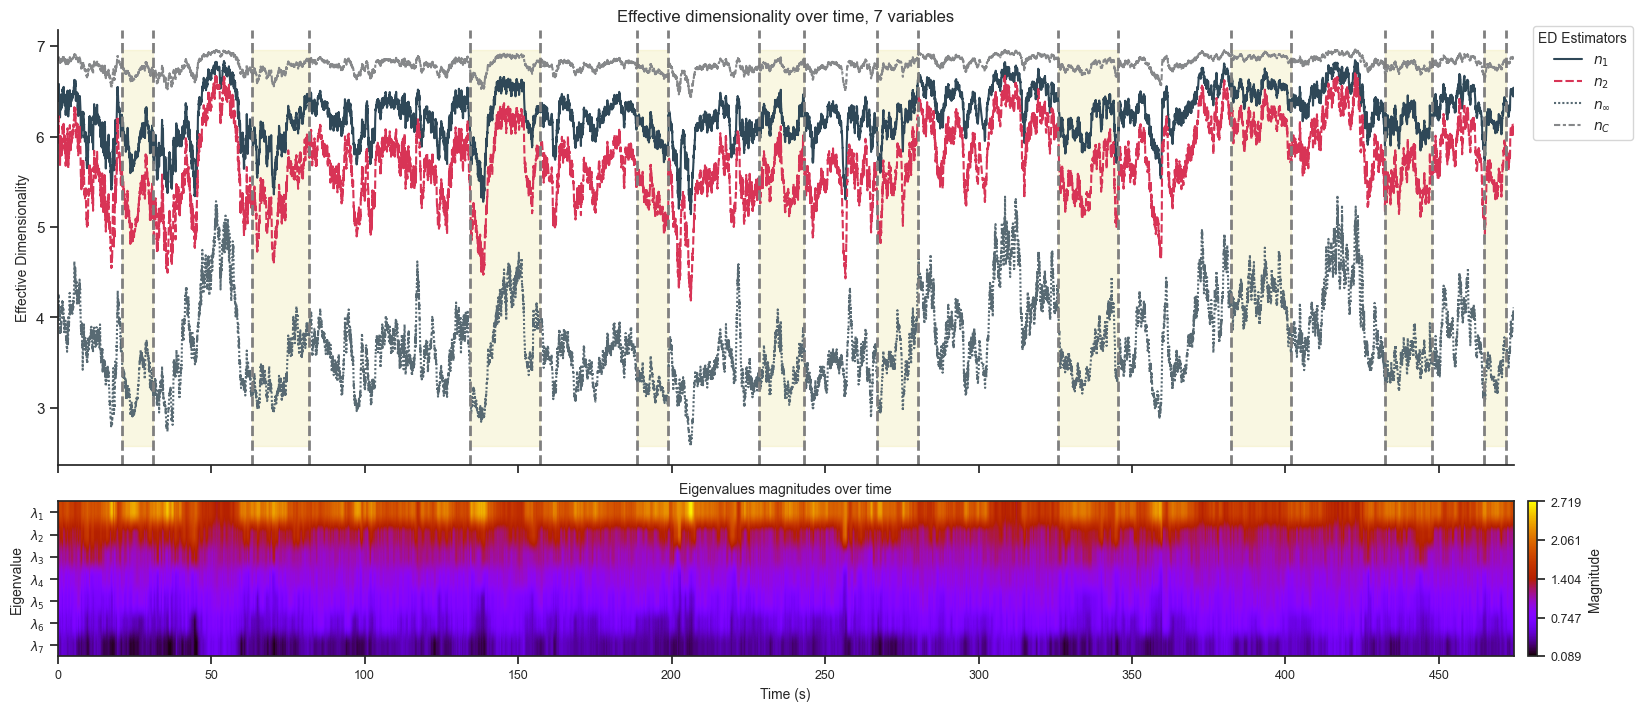

In [16]:
# Visualize ED over recording time
results_df = create_combined_visualization(
    eigenvalues_df=eigenv_df,
    ed_df=ed_df,  # Your list of features, or None
    cmap= "gnuplot", #"jet",#"inferno", #"gnuplot",
    save=False,
    save_name = 'ED_and_eigval_magnitudes'
)

Visualize different ED estimators at event onset

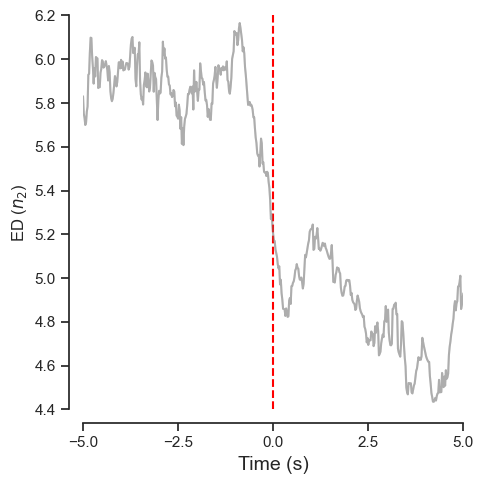

In [15]:
# Specify the metric to visualize of '' for all metric 
metric = 'n2' 

ed_df_single_event = ed_df[(ed_df['Event'] == 'three') | (ed_df['Event'] == 'three_BE')]
# Visualize different ED estimators around event onset
results_df_metric = vis_ed_at_onset(
    ed_df_single_event, event_col='Event', 
    time_col='Time', 
    window=5, 
    save=False, 
    metric=metric, 
    save_name=f'ed_{metric}_around_event_onset_all_events'
)

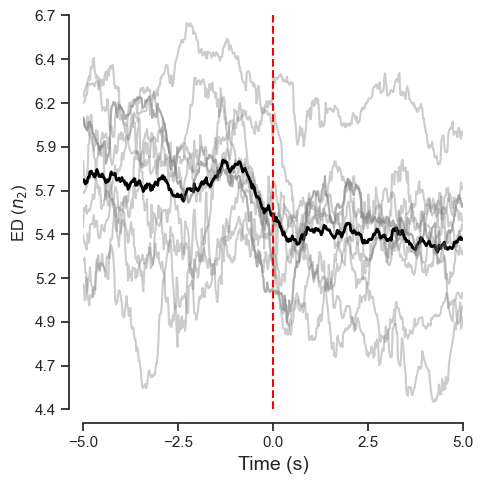

In [45]:
# Specify the metric to visualize of '' for all metric 
metric = 'n2' 

# ed_df_single_event = ed_df[(ed_df['Event'] == 'three') | (ed_df['Event'] == 'three_BE')]
# Visualize different ED estimators around event onset
_ = vis_ed_at_onset(
    ed_df, event_col='Event', 
    time_col='Time', 
    window=5, 
    save=False, 
    metric=metric, 
    save_name=f'ed_{metric}_around_event_onset_all_events'
)

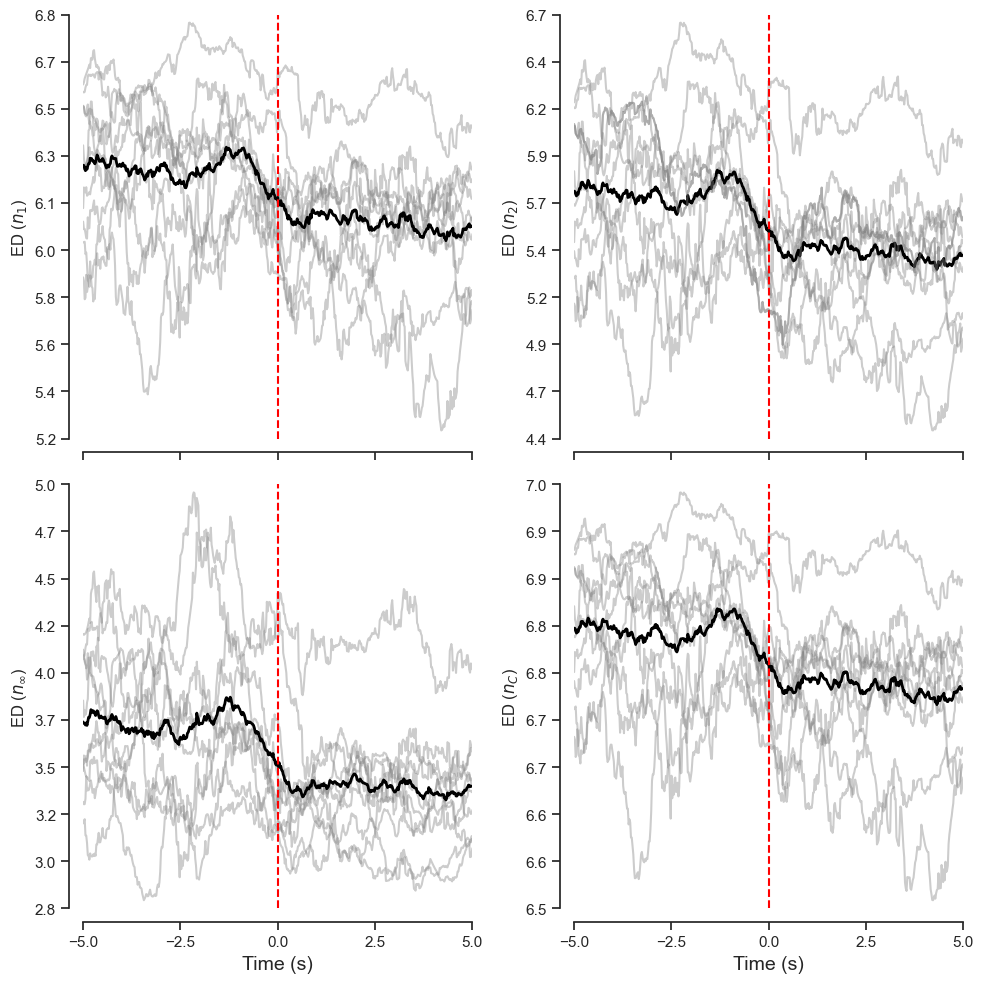

In [47]:
# Specify the metric to visualize of '' for all metric 
metric = '' 

# ed_df_single_event = ed_df[(ed_df['Event'] == 'three') | (ed_df['Event'] == 'three_BE')]
# Visualize different ED estimators around event onset
results_df_all_metrics = vis_ed_at_onset(
    ed_df, event_col='Event', 
    time_col='Time', 
    window=5, 
    save=False, 
    metric=metric, 
    save_name=f'ed_{metric}_around_event_onset_all_events'
)

In [48]:
results_df_all_metrics

,event,onset_time,relative_time,variable,value,Timepoint
0,one,20.84,-5.00,n1,5.852104,BO
1,one,20.84,-4.98,n1,5.838857,BO
2,one,20.84,-4.96,n1,5.770133,BO
3,one,20.84,-4.94,n1,5.775700,BO
4,one,20.84,-4.92,n1,5.861793,BO
...,...,...,...,...,...,...
20035,ten,464.62,4.92,nC,6.791606,AO
20036,ten,464.62,4.94,nC,6.786149,AO
20037,ten,464.62,4.96,nC,6.781989,AO
20038,ten,464.62,4.98,nC,6.782209,AO


In [49]:
print(results_df_all_metrics.drop(columns=['onset_time', 'relative_time'], inplace=False))

      event variable     value Timepoint
0       one       n1  5.852104        BO
1       one       n1  5.838857        BO
2       one       n1  5.770133        BO
3       one       n1  5.775700        BO
4       one       n1  5.861793        BO
...     ...      ...       ...       ...
20035   ten       nC  6.791606        AO
20036   ten       nC  6.786149        AO
20037   ten       nC  6.781989        AO
20038   ten       nC  6.782209        AO
20039   ten       nC  6.785975        AO

[20000 rows x 4 columns]


# 3. Comparing ED before versus after event onset 

In [50]:
def label_bo_ao_excluding_onset(
        df: pd.DataFrame,
        relative_time_col: str = 'relative_time',
        timepoint_col: str = 'Timepoint'
) -> pd.DataFrame:
    """
    Create a BO/AO timepoint label while excluding the onset (t == 0) sample.

    - BO covers times strictly before onset: (-inf, 0)
    - AO covers times strictly after onset:  (0, +inf)

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe that should contain a relative-time column.
    relative_time_col : str
        Column name with time relative to event onset (seconds).
    timepoint_col : str
        Name of the column to create with labels {'BO','AO'}.

    Returns
    -------
    pd.DataFrame
        Copy of df with onset removed and a `timepoint_col` label.
    """

    if relative_time_col not in df.columns:
        # If relative time is not available, return df as-is (no relabeling possible)
        return df.copy()

    out = df.copy()
    mask0 = np.isclose(out[relative_time_col], 0.0)
    out = out.loc[~mask0].copy()
    out[timepoint_col] = np.where(out[relative_time_col] < 0, 'BO', 'AO')
    return out


def compute_event_level_bo_ao_stats(
        df: pd.DataFrame,
        metric: str,
        event_col: str = 'event',
        variable_col: str = 'variable',
        value_col: str = 'value',
        timepoint_col: str = 'Timepoint',
        relative_time_col: str = 'relative_time'
) -> pd.DataFrame:
    """
    Compute per-event BO/AO mean, SD, SEM for one metric and the standardized
    difference components used in the inverse-variance–weighted chi-square.

    Returns a dataframe with one row per event and the following columns:
        - mean_BO, mean_AO, std_BO, std_AO, n_BO, n_AO, sem_BO, sem_AO
        - delta = mean_AO - mean_BO
        - denom = sqrt(sem_AO^2 + sem_BO^2)
        - z = delta / denom
        - z2 = z**2
    """
    
    # Ensure BO/AO labels with onset excluded
    labeled = label_bo_ao_excluding_onset(df, relative_time_col=relative_time_col, timepoint_col=timepoint_col)

    # Filter to the requested metric
    metric_df = labeled.loc[labeled[variable_col] == metric].copy()

    if metric_df.empty:
        return pd.DataFrame(columns=[
            event_col, 'mean_BO', 'mean_AO', 'sd_BO', 'sd_AO', 'n_BO', 'n_AO',
            'sem_BO', 'sem_AO', 'delta', 'denom', 'z', 'z2'
        ])

    # Aggregate per event and timepoint
    grouped = (
        metric_df
        .groupby([event_col, timepoint_col], observed=True)[value_col]
        .agg(count='count', mean='mean', std='std')
        .reset_index()
    )

    # Pivot to wide format: columns like count_BO, mean_AO, std_BO, ...
    wide = grouped.pivot(index=event_col, columns=timepoint_col)
    # Flatten MultiIndex columns
    wide.columns = [f"{stat}_{tp}" for stat, tp in wide.columns]
    wide = wide.reset_index()

    # Compute SEMs, deltas, standardization; guard against missing columns
    for col in ['count_BO', 'count_AO', 'std_BO', 'std_AO', 'mean_BO', 'mean_AO']:
        if col not in wide.columns:
            wide[col] = np.nan

    # Convert counts to float to avoid integer division surprises
    n_bo = wide['count_BO'].astype(float)
    n_ao = wide['count_AO'].astype(float)

    # Robust SEM: when n<=1, set SEM to 0 (std is undefined with ddof=1)
    wide['sem_BO'] = np.where(n_bo > 1.0, wide['std_BO'] / np.sqrt(n_bo), 0.0)
    wide['sem_AO'] = np.where(n_ao > 1.0, wide['std_AO'] / np.sqrt(n_ao), 0.0)

    wide['delta'] = wide['mean_AO'] - wide['mean_BO']

    # Denominator with numerical safety
    denom = np.sqrt(np.square(wide['sem_AO']) + np.square(wide['sem_BO']))
    # Replace zeros or extremely small values to avoid division blow-ups
    eps = np.finfo(float).eps
    denom = denom.replace(0.0, np.sqrt(eps))
    wide['denom'] = denom

    wide['z'] = wide['delta'] / wide['denom']
    wide['z2'] = np.square(wide['z'])

    # Keep a clean column ordering
    cols = [
        event_col,
        'mean_BO', 'mean_AO', 'std_BO', 'std_AO', 'count_BO', 'count_AO',
        'sem_BO', 'sem_AO', 'delta', 'denom', 'z', 'z2'
    ]
    # Some datasets may miss sd_* if single sample; ensure presence
    for c in cols:
        if c not in wide.columns:
            wide[c] = np.nan
    return wide[cols]


def holm_bonferroni_adjust(p_values: List[float]) -> List[float]:
    """
    Holm–Bonferroni step-down adjustment. Returns adjusted p-values in the
    original order.
    """
    p = np.asarray(p_values, dtype=float)
    m = p.size
    if m == 0:
        return []
    order = np.argsort(p)
    ordered = p[order]
    factors = (m - np.arange(m))
    adjusted_ordered = np.maximum.accumulate(ordered * factors)
    adjusted_ordered = np.clip(adjusted_ordered, 0.0, 1.0)
    adjusted = np.empty_like(adjusted_ordered)
    adjusted[order.argsort()] = adjusted_ordered
    return adjusted.tolist()


def weighted_chi_square_test_for_metric(
        df: pd.DataFrame,
        metric: str,
        event_col: str = 'event',
        variable_col: str = 'variable',
        value_col: str = 'value',
        timepoint_col: str = 'Timepoint',
        relative_time_col: str = 'relative_time'
) -> Dict[str, object]:
    """
    Implements the supervisor's chi-square formulation for a single metric,
    treating events as independent observations with per-event inverse-variance
    weights.

    Chi-square statistic:
        chi2_stat = sum_i [ ((AO_i - BO_i) / sqrt(SEM_AO_i^2 + SEM_BO_i^2))^2 ]

    Degrees of freedom = number of events included.

    Also returns the inverse-variance weighted mean difference and its 95% CI.
    """
    from scipy.stats import chi2, norm
    per_event = compute_event_level_bo_ao_stats(
        df=df,
        metric=metric,
        event_col=event_col,
        variable_col=variable_col,
        value_col=value_col,
        timepoint_col=timepoint_col,
        relative_time_col=relative_time_col
    )

    # Drop rows with missing denominators or deltas
    valid = per_event.dropna(subset=['denom', 'delta'])
    if valid.empty:
        return {
            'metric': metric,
            'num_events': 0,
            'chi2': np.nan,
            'df': 0,
            'p_value': np.nan,
            'weighted_mean_diff': np.nan,
            'ci_lower': np.nan,
            'ci_upper': np.nan,
            'per_event': per_event
        }

    z2_sum = valid['z2'].sum()
    df_events = valid.shape[0]
    # Compute p-value in log-space to avoid underflow; with robust fallbacks
    log_p = chi2.logsf(z2_sum, df_events)
    p_source = 'scipy-chi2'
    if not np.isfinite(log_p):
        # Try high-precision evaluation using mpmath if available
        try:
            import mpmath as mp
            mp.mp.dps = 80  # precision in decimal digits
            a = df_events / 2.0
            x = z2_sum / 2.0
            # Survival for Gamma(a, scale=1) at x is Q(a, x) = upper_regularized_gamma
            # For chi2, scale=2, so we evaluate at x=z2_sum/2
            Q = mp.gammainc(a, x, mp.inf) / mp.gamma(a)
            log_p = float(mp.log(Q))
            p_val = float(Q) if Q > 0 else 0.0
            neg_log10_p = float(-mp.log(Q) / mp.log(10))
            # Display format starting with 0.000 for very small p-values
            if p_val == 0.0 or neg_log10_p >= 3:
                p_value_str = f"0.000 (<1e-{int(np.floor(neg_log10_p))})" if p_val == 0.0 else f"0.000 (≈ {p_val:.2e})"
            else:
                p_value_str = f"{p_val:.6f}"
            p_source = 'mpmath'
        except Exception:
            # Wilson–Hilferty normal approximation
            z_wh = ((z2_sum / df_events) ** (1.0 / 3.0) - (1 - 2.0 / (9.0 * df_events))) / np.sqrt(2.0 / (9.0 * df_events))
            log_p = norm.logsf(z_wh)
            tiny_log = np.log(np.finfo(float).tiny)
            p_val = float(np.exp(log_p)) if log_p > tiny_log else 0.0
            neg_log10_p = float(-log_p / np.log(10))
            p_value_str = f"0.000 (<1e-{int(np.floor(neg_log10_p))})" if p_val == 0.0 else f"0.000 (≈ {p_val:.2e})"
            p_source = 'wilson-hilferty'
    else:
        tiny_log = np.log(np.finfo(float).tiny)
        p_val = float(np.exp(log_p)) if log_p > tiny_log else 0.0
        neg_log10_p = float(-log_p / np.log(10))
        if p_val == 0.0 or neg_log10_p >= 3:
            p_value_str = f"0.000 (<1e-{int(np.floor(neg_log10_p))})" if p_val == 0.0 else f"0.000 (≈ {p_val:.2e})"
        else:
            p_value_str = f"{p_val:.6f}"

    # Inverse-variance weighted mean difference and CI
    weights = 1.0 / np.square(valid['denom'])
    weighted_delta = np.sum(weights * valid['delta']) / np.sum(weights)
    se_weighted = 1.0 / np.sqrt(np.sum(weights))
    ci_low = weighted_delta - 1.96 * se_weighted
    ci_high = weighted_delta + 1.96 * se_weighted

    return {
        'metric': metric,
        'num_events': int(df_events),
        'chi2': float(z2_sum),
        'df': int(df_events),
        # Report string-form p-value for readability
        'p_value': p_value_str,
        # Keep numeric p for downstream adjustments/use
        # 'p_value_float': float(p_val),
        # 'p_source': p_source,
        'weighted_mean_diff': float(weighted_delta),
        'ci_lower': float(ci_low),
        'ci_upper': float(ci_high),
        'per_event': valid.reset_index(drop=True)
    }


def weighted_chi_square_all_metrics(
        df: pd.DataFrame,
        metrics: Optional[Iterable[str]] = None,
        event_col: str = 'event',
        variable_col: str = 'variable',
        value_col: str = 'value',
        timepoint_col: str = 'Timepoint',
        relative_time_col: str = 'relative_time',
        adjust_method: Optional[str] = 'holm'
) -> pd.DataFrame:
    """
    Run the inverse-variance weighted chi-square test across all requested
    metrics and return a tidy results dataframe. Optionally applies
    Holm–Bonferroni adjustment across metrics.
    """

    if metrics is None:
        metrics = (
            df[variable_col].dropna().unique().tolist()
        )

    results: List[Dict[str, object]] = []
    for m in metrics:
        res = weighted_chi_square_test_for_metric(
            df=df,
            metric=m,
            event_col=event_col,
            variable_col=variable_col,
            value_col=value_col,
            timepoint_col=timepoint_col,
            relative_time_col=relative_time_col
        )
        results.append({k: v for k, v in res.items() if k != 'per_event'})

    out = pd.DataFrame(results)
    if out.empty:
        return out

    if adjust_method is not None:
        if adjust_method.lower() in {'holm', 'holm-bonferroni', 'holm_bonferroni'}:
            # Use numeric p-values for adjustment
            if 'p_value_float' in out.columns:
                p_adj_float = holm_bonferroni_adjust(out['p_value_float'].tolist())
            else:
                # Fallback: try to coerce string p-values
                p_adj_float = holm_bonferroni_adjust(pd.to_numeric(out['p_value'], errors='coerce').fillna(0.0).tolist())
            out['p_adj_float'] = p_adj_float
            # String formatting for adjusted p-values with same style as p_value
            m = len(out)
            formatted = []
            for i, p in enumerate(p_adj_float):
                base_str = str(out.loc[i, 'p_value']) if 'p_value' in out.columns else None
                base_float = float(out.loc[i, 'p_value_float']) if 'p_value_float' in out.columns else np.nan
                # Estimate factor used by Holm for this row
                if np.isfinite(base_float) and base_float > 0 and np.isfinite(p) and p > 0:
                    factor_est = p / base_float
                else:
                    factor_est = m  # conservative bound

                if np.isfinite(p) and p > 0:
                    if p < 1e-3:
                        formatted.append(f"0.000 (≈ {p:.2e})")
                    else:
                        formatted.append(f"{p:.6f}")
                else:
                    # Try to parse exponent from the base p_value string
                    exp = None
                    if base_str is not None:
                        m1 = re.search(r"<1e-(\d+)", base_str)
                        if m1:
                            exp = int(m1.group(1))
                        else:
                            m2 = re.search(r"≈\s*[0-9.]+e-([0-9]+)", base_str)
                            if m2:
                                exp = int(m2.group(1))
                    if exp is None:
                        exp = 308
                    adj_exp = max(1, int(np.floor(exp - np.log10(factor_est))))
                    formatted.append(f"0.000 (<1e-{adj_exp})")
            out['p_adj'] = formatted
        else:
            out['p_adj'] = out.get('p_value', None)

    # Order by metric appearance
    return out

In [51]:
res = weighted_chi_square_test_for_metric(results_df_all_metrics, metric='n2')

p_txt = res['p_value']                       # string, e.g., '0.000 (<1e-138)' or '0.012345'
p_num = res.get('p_value_float', np.nan)     # numeric (0.0 if underflow)

eq = '='

# optional: a readable -log10 p summary
if np.isfinite(p_num) and p_num > 0:
    neglog10_txt = f"{-np.log10(p_num):.1f}"
else:
    m = re.search(r'<1e-(\\d+)', p_txt)
    neglog10_txt = f">{m.group(1)}" if m else "NA"

print(
    f"χ²({res['df']}, \x1b[3mN\x1b[0m = {res['num_events']}) = {res['chi2']:.2f}, "
    f"p {eq} {p_txt}, Δ̂ = {res['weighted_mean_diff']:.3f} "
    f"[{res['ci_lower']:.3f}, {res['ci_upper']:.3f}]"
)
res['per_event']

χ²(10, N = 10) = 8025.01, p = 0.000 (<1e-1729), Δ̂ = -0.275 [-0.285, -0.266]


,event,mean_BO,mean_AO,std_BO,std_AO,count_BO,count_AO,sem_BO,sem_AO,delta,denom,z,z2
0,eight,6.295733,6.121015,0.168269,0.127141,250,250,0.010642,0.008041,-0.174718,0.013339,-13.098698,171.575891
1,five,5.350972,5.556640,0.115975,0.132841,250,250,0.007335,0.008402,0.205668,0.011153,18.440766,340.061835
2,four,5.742899,5.437349,0.113347,0.124049,250,250,0.007169,0.007846,-0.305550,0.010627,-28.750964,826.617934
3,nine,5.712774,5.465970,0.167854,0.144374,250,250,0.010616,0.009131,-0.246805,0.014003,-17.625531,310.659355
4,one,5.313307,5.134401,0.419710,0.213417,250,250,0.026545,0.013498,-0.178906,0.029779,-6.007705,36.092525
5,seven,6.139641,5.504343,0.129784,0.166354,250,250,0.008208,0.010521,-0.635298,0.013344,-47.608160,2266.536939
6,six,5.527549,5.349523,0.228965,0.258118,250,250,0.014481,0.016325,-0.178026,0.021822,-8.158077,66.554224
7,ten,5.834901,5.458356,0.287337,0.180567,250,250,0.018173,0.011420,-0.376546,0.021463,-17.543800,307.784920
8,three,5.873698,4.869090,0.158461,0.210270,250,250,0.010022,0.013299,-1.004609,0.016652,-60.329162,3639.607812
9,two,5.366514,5.202212,0.266427,0.205946,250,250,0.016850,0.013025,-0.164302,0.021298,-7.714579,59.514722


In [52]:
print(res)

{'metric': 'n2', 'num_events': 10, 'chi2': 8025.006157085838, 'df': 10, 'p_value': '0.000 (<1e-1729)', 'weighted_mean_diff': -0.27539760916147304, 'ci_lower': -0.2846952602274484, 'ci_upper': -0.2660999580954977, 'per_event':    event   mean_BO   mean_AO    std_BO    std_AO  count_BO  count_AO  \
0  eight  6.295733  6.121015  0.168269  0.127141       250       250   
1   five  5.350972  5.556640  0.115975  0.132841       250       250   
2   four  5.742899  5.437349  0.113347  0.124049       250       250   
3   nine  5.712774  5.465970  0.167854  0.144374       250       250   
4    one  5.313307  5.134401  0.419710  0.213417       250       250   
5  seven  6.139641  5.504343  0.129784  0.166354       250       250   
6    six  5.527549  5.349523  0.228965  0.258118       250       250   
7    ten  5.834901  5.458356  0.287337  0.180567       250       250   
8  three  5.873698  4.869090  0.158461  0.210270       250       250   
9    two  5.366514  5.202212  0.266427  0.205946      

In [53]:
weighted_chi_square_all_metrics(
        results_df_all_metrics,
        metrics= ['n1', 'n2', 'nInf', 'nC'],
)

,metric,num_events,chi2,df,p_value,weighted_mean_diff,ci_lower,ci_upper,p_adj_float,p_adj
0,n1,10,6269.599076,10,0.000 (<1e-1348),-0.157561,-0.163744,-0.151378,0.0,0.000 (<1e-1347)
1,n2,10,8025.006157,10,0.000 (<1e-1729),-0.275398,-0.284695,-0.266100,0.0,0.000 (<1e-1728)
2,nInf,10,9493.136557,10,0.000 (<1e-2048),-0.313828,-0.322740,-0.304915,0.0,0.000 (<1e-2047)
3,nC,10,7281.275600,10,0.000 (<1e-1568),-0.049654,-0.051432,-0.047876,0.0,0.000 (<1e-1567)
